In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

BASE_DIR = Path().resolve().parent 

file_path = BASE_DIR / "data" / "processed" / "cleaned_Churn.csv"

sns.set_style("whitegrid")

df = pd.read_csv(file_path)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,IsNewCustomer
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0


### Target Variable Analysis: Churn Distribution

We now examine the distribution of the target variable (Churn) to understand class balance. This is important because imbalanced datasets can affect model performance and evaluation metrics.

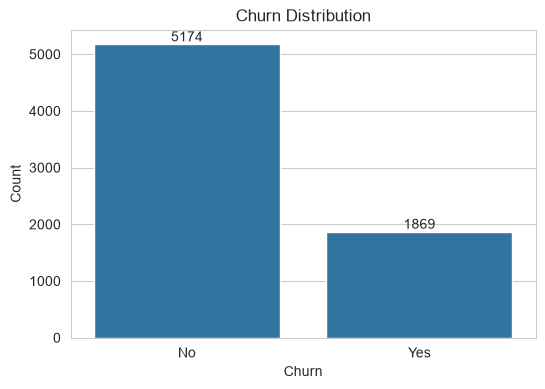

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

ax = sns.countplot(data=df, x="Churn")

# Add values on top of bars
for container in ax.containers:
    ax.bar_label(container)

plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()


In [3]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

### Contract Type vs Churn

This analysis explores the relationship between customer contract type and churn behavior to understand whether contract duration influences customer retention.

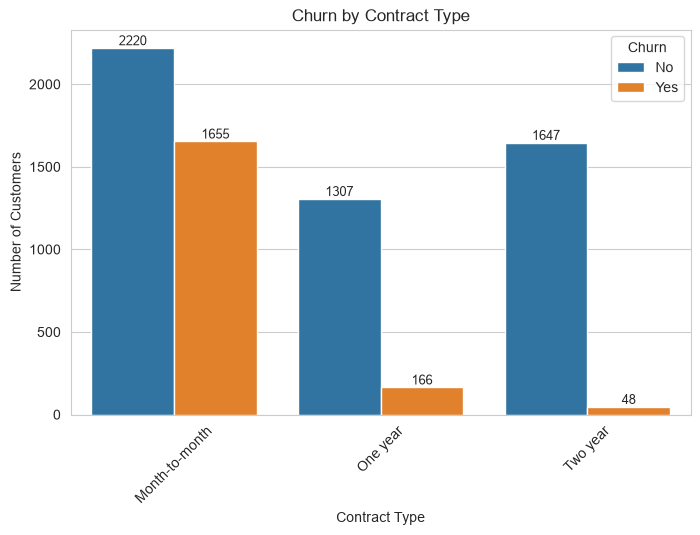

In [11]:
plt.figure(figsize=(8,5))

ax = sns.countplot(data=df, x="Contract", hue="Churn")

# Better labeling (less cluttered approach)
for container in ax.containers:
    ax.bar_label(container, fontsize=9)

plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)

plt.legend(title="Churn")

plt.show()

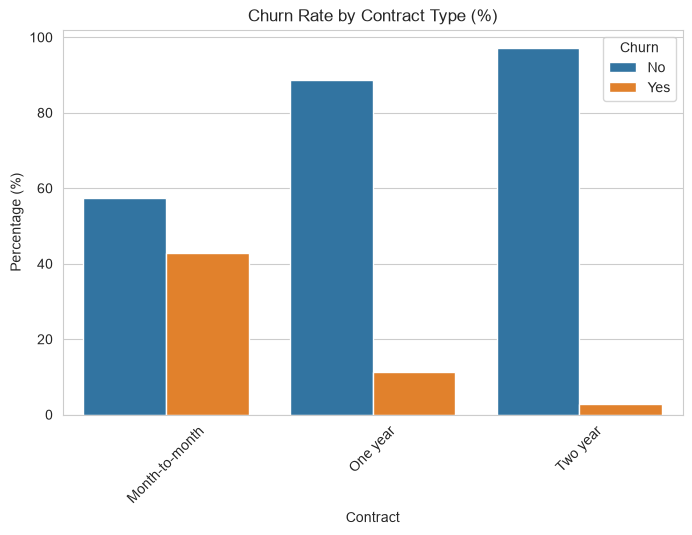

In [10]:
contract_churn = (
    df.groupby("Contract")["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("percentage")
    .reset_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=contract_churn,
    x="Contract",
    y="percentage",
    hue="Churn"
)

plt.title("Churn Rate by Contract Type (%)")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45)

plt.show()

### Customer Tenure Analysis

This analysis examines the distribution of customer tenure to understand how long customers typically remain with the company. Tenure represents the number of months a customer has stayed with the service and serves as a key indicator of customer loyalty.


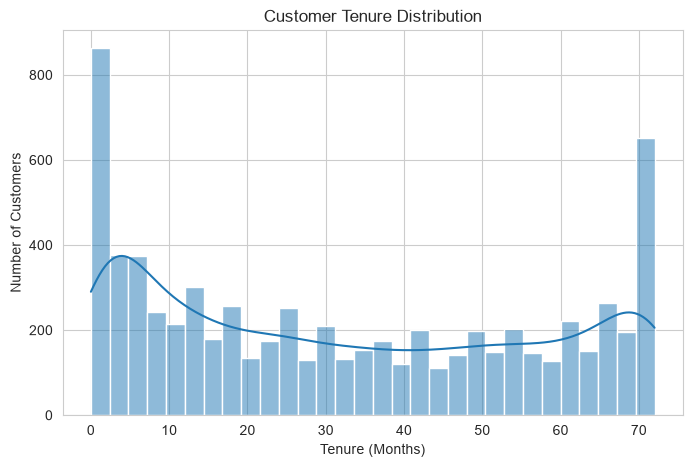

In [5]:
plt.figure(figsize=(8, 5))

sns.histplot(df["tenure"], bins=30, kde=True)

plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

### Monthly Charges vs Churn

This analysis examines the relationship between monthly charges and customer churn to determine whether pricing influences a customer's likelihood of leaving the service.

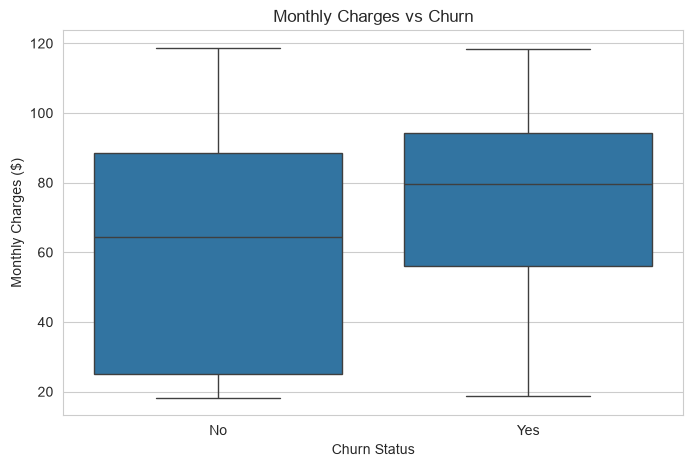

In [6]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn Status")
plt.ylabel("Monthly Charges ($)")

plt.show()

### Internet Service vs Churn

This analysis explores the relationship between internet service type and customer churn to determine whether certain service offerings are associated with higher customer attrition.

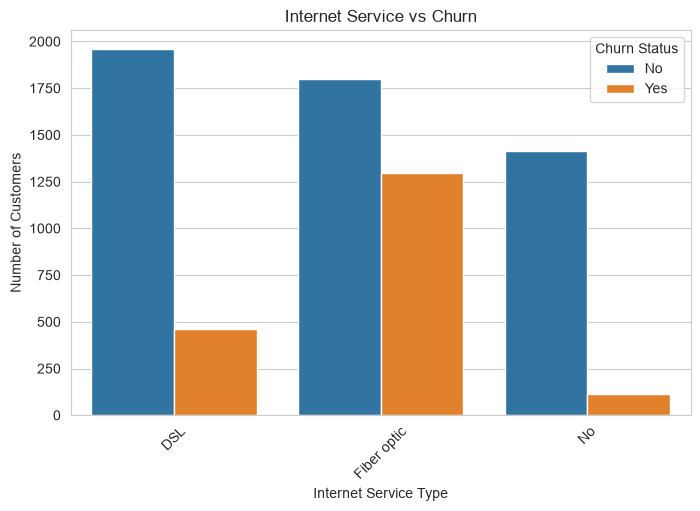

In [7]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.title("Internet Service vs Churn")
plt.xlabel("Internet Service Type")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.legend(title="Churn Status")

plt.show()

### Payment Method vs Churn

This analysis investigates the relationship between a customer's payment method and their likelihood of churning. Payment behavior can provide valuable insights into customer preferences, convenience, and engagement with the service.

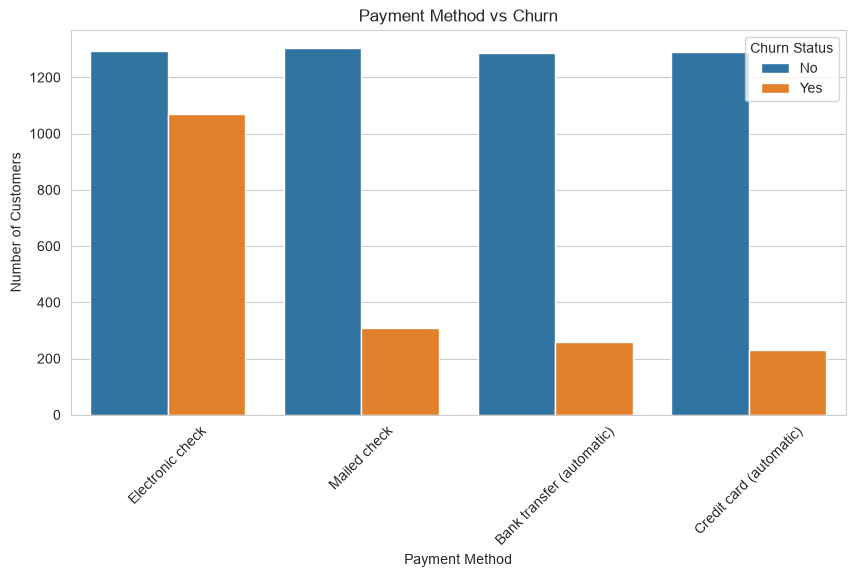

In [8]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

plt.title("Payment Method vs Churn")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.legend(title="Churn Status")

plt.show()

### Correlation Analysis (Feature Relationships)

This analysis examines the correlation between numerical features in the dataset to understand how variables interact with each other and with potential churn drivers.

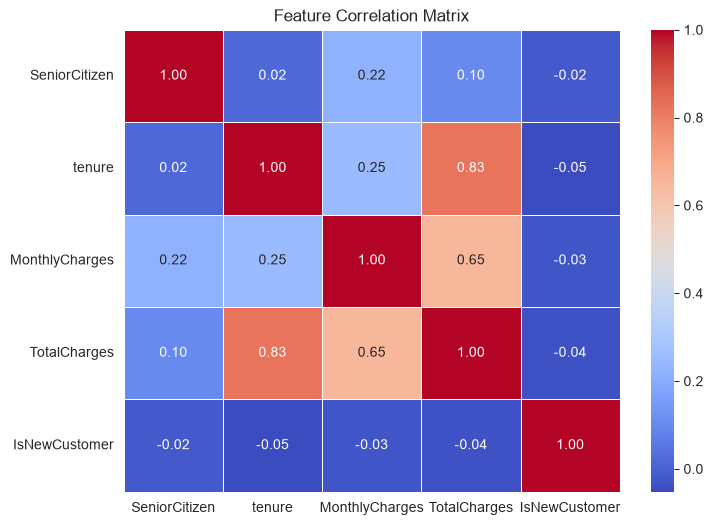

In [9]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Feature Correlation Matrix")
plt.show()

## Key EDA Insights

-   Overall churn rate is 26.5% (1,869 churned vs. 5,174 retained out of 7,043 customers) — roughly 1 in 4 customers leaves, indicating a churn problem of meaningful scale, not a marginal one.

-   Contract type is the single largest visible separator of churn outcomes: month-to-month customers churn at 42.7%, versus 11.3% for one-year and 2.8% for two-year contracts.

-   Customer tenure shows two major groups. A large number of customers are either very new to the company (close to 0 months of tenure) or have been with the company for a long time (70+ months). There are fewer customers in the middle tenure range (20–60 months). This suggests the customer base consists of a sizeable group of new customers who may still be deciding whether to stay, and a loyal group of long-term customers who are less likely to leave.

-   Tenure has a strong positive correlation with TotalCharges (r = 0.83), indicating that customers who have been with the company longer naturally accumulate higher total charges over time. This suggests that TotalCharges largely reflects customer lifespan rather than serving as an independent driver of churn.

-   Internet service type appears to be a strong driver of churn. Fiber Optic customers have the highest churn rate (42%), more than double that of DSL customers (19%) and six times that of customers without internet service (7%). This makes Fiber Optic subscribers one of the most vulnerable customer segments in the dataset.

-   Customers who churn tend to pay higher monthly charges than those who remain with the company. The median monthly charge for churned customers is approximately $79–80, compared to about $64 for retained customers. This suggests that higher monthly costs may be contributing to customer dissatisfaction and increasing the likelihood of churn

-   Customers using electronic check as a payment method have the highest churn rate, with approximately 45% (about 1,071 of 2,361 customers) leaving the service. This is significantly higher than other payment methods such as mailed check (~19%), bank transfer (~17%), and credit card (~15%). This suggests that electronic check users represent a high-risk customer segment.


### Overall Interpretation

Customer churn in this dataset is driven by a combination of contract structure, customer lifecycle stage, pricing, service type, and payment behavior rather than a single isolated factor. Several consistent patterns emerge across the analysis that help explain why customers are leaving.

### Why Customers Are Churning

-   Overall, churn is not driven by a single factor but by a combination of structural, behavioral, and service-related attributes. The strongest signals indicate that customers are more likely to churn when they are on flexible month-to-month contracts, in the early stages of their customer journey, paying higher monthly fees, using Fiber optic internet services, and relying on electronic check payments.

These patterns suggest that improving early customer experience, encouraging longer-term contracts, and reviewing pricing and service delivery for high-risk segments could significantly reduce churn.